In [1]:
%load_ext autoreload
%autoreload 2

# SRE-DQN vs Nash-DQN Visualization

Load the latest saved Nash/SRE checkpoints from `pt_files/` and generate comparison plots/evaluation artifacts.

In [2]:
import os
import pickle
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy import stats

from NashRL import collect_parallel_rollouts
from NashAgent_lib import NashNN
from linear_approximation.sre_agent import SreNN
from visualization import draw_heatmap, to_State_mesh, to_State_mesh_sre
from experiment_config import seed_everything

np.set_printoptions(precision=4)


def load_best_checkpoint_into_agent(agent, model_dir):
    checkpoint_path = os.path.join(model_dir, 'best_checkpoint', 'checkpoint.pt')
    device = next(agent.action_net.parameters()).device
    try:
        checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    except TypeError:
        checkpoint = torch.load(checkpoint_path, map_location=device)
    agent.action_net.load_state_dict(checkpoint['action_net_state_dict'])
    agent.value_net.load_state_dict(checkpoint['value_net_state_dict'])
    if hasattr(agent, 'slow_val_net') and 'slow_val_net_state_dict' in checkpoint:
        agent.slow_val_net.load_state_dict(checkpoint['slow_val_net_state_dict'])
    agent.action_net.eval()
    agent.value_net.eval()
    if hasattr(agent, 'slow_val_net'):
        agent.slow_val_net.eval()
    return checkpoint_path, checkpoint


def build_nash_agent_from_config():
    return NashNN(**NET_KWARGS)


def build_sre_agent_from_config():
    return SreNN(
        **NET_KWARGS,
        eps_reg=SRE_EPS_REG,
        delta_min=SRE_DELTA_MIN,
        gamma=SRE_GAMMA,
    )


def loss_history_from_checkpoint(checkpoint):
    loss_arr = checkpoint.get('sum_loss')
    if loss_arr is None:
        return None
    loss_arr = np.asarray(loss_arr)
    iteration = int(checkpoint.get('iteration', len(loss_arr) - 1))
    end = min(iteration + 1, len(loss_arr))
    return loss_arr[:end]


def find_latest_model_dir(prefix, root_dir='pt_files'):
    if not os.path.isdir(root_dir):
        raise FileNotFoundError(f"Model root directory not found: {root_dir}")

    candidates = []
    for name in os.listdir(root_dir):
        full_path = os.path.join(root_dir, name)
        checkpoint_path = os.path.join(full_path, 'best_checkpoint', 'checkpoint.pt')
        if name.startswith(prefix + '_') and os.path.isfile(checkpoint_path):
            candidates.append(full_path)

    if not candidates:
        raise FileNotFoundError(
            f"No saved model directory with checkpoint found for prefix {prefix!r} under {root_dir!r}"
        )

    return max(candidates, key=lambda path: os.path.basename(path))


print('Using device:', 'cuda' if torch.cuda.is_available() else 'cpu')


Using device: cuda


## Shared Market Environment

Identical parameters to `NashDQN-Training.ipynb`. Both agents are trained on this same environment.

In [3]:
from experiment_config import (
    NUM_PLAYERS as num_players, sim_dict, norm_mean, norm_std, T, make_sim_obj,
)

sim_obj = make_sim_obj()

print('Agents:', num_players, '| T=', sim_dict['T'].item(), '| dt=', sim_dict['dt'].item())


Agents: 5 | T= 5 | dt= 0.5


/tmp/ipykernel_15093/3308847593.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sim_dict['initial_price_var'] = torch.tensor(inv_std).cuda().detach()


## Visualization Configuration


In [ ]:
from experiment_config import (
    seed_everything, eps_slug,
    BASE_SEED, MAX_STEPS,
    SRE_EPS_LIST, SRE_EPS_REG,
)

# Visualization-specific config
EVAL_SEED = BASE_SEED + 1

RUN_TAG = datetime.now().strftime('%Y%m%d_%H%M')

MODEL_ROOT = 'pt_files'
NASH_MODEL_DIR = find_latest_model_dir('nash', root_dir=MODEL_ROOT)
SRE_MODEL_DIRS = {
    eps: find_latest_model_dir(f'sre_eps_{eps_slug(eps)}', root_dir=MODEL_ROOT)
    for eps in SRE_EPS_LIST
}
EVAL_DIR = os.path.join('evaluation', RUN_TAG)
os.makedirs(EVAL_DIR, exist_ok=True)

seed_everything(BASE_SEED)

print('Loaded Nash model dir:', NASH_MODEL_DIR)
print('Loaded SRE model dirs:')
for eps in SRE_EPS_LIST:
    print(f'  eps={eps:g}:', SRE_MODEL_DIRS[eps])
print('Evaluation dir:', EVAL_DIR)
print('Seeds | base:', BASE_SEED, '| eval:', EVAL_SEED)


Loaded Nash model dir: pt_files/nash_20260409_1801
Loaded SRE model dirs:
  eps=0: pt_files/sre_eps_0_20260409_1801
  eps=0.01: pt_files/sre_eps_0p01_20260409_1801
  eps=0.1: pt_files/sre_eps_0p1_20260409_1801
  eps=0.5: pt_files/sre_eps_0p5_20260409_1801
  eps=1: pt_files/sre_eps_1_20260409_1801
Evaluation dir: evaluation/20260411_2312
Seeds | base: 20260409 | eval: 20260410



## Load Best Checkpoints

Run this cell after the training notebook has saved checkpoints to restore the latest best Nash/SRE models before plotting heatmaps and evaluations.


In [5]:
nash_agent = build_nash_agent_from_config()
nash_best_checkpoint_path, nash_best_checkpoint = load_best_checkpoint_into_agent(nash_agent, NASH_MODEL_DIR)
nash_loss = loss_history_from_checkpoint(nash_best_checkpoint)
print(
    f"Loaded Nash best checkpoint from iteration {nash_best_checkpoint['iteration']} "
    f"with loss {nash_best_checkpoint['best_loss']:.4f}"
)

sre_agents = {}
sre_losses = {}
sre_best_checkpoint_paths = {}
sre_best_checkpoints = {}
for eps in SRE_EPS_LIST:
    sre_agents[eps] = build_sre_agent_from_config()
    checkpoint_path, checkpoint = load_best_checkpoint_into_agent(sre_agents[eps], SRE_MODEL_DIRS[eps])
    sre_best_checkpoint_paths[eps] = checkpoint_path
    sre_best_checkpoints[eps] = checkpoint
    sre_losses[eps] = loss_history_from_checkpoint(checkpoint)
    print(
        f"Loaded SRE best checkpoint (eps={eps:g}) from iteration {checkpoint['iteration']} "
        f"with loss {checkpoint['best_loss']:.4f}"
    )

print('Loaded all requested SRE best checkpoints.')


CUDA IS AVAILABLE!
Loaded Nash best checkpoint from iteration 6101 with loss 35.9072
CUDA IS AVAILABLE!
Loaded SRE best checkpoint (eps=0) from iteration 6101 with loss 35.9075
CUDA IS AVAILABLE!
Loaded SRE best checkpoint (eps=0.01) from iteration 6101 with loss 35.8644
CUDA IS AVAILABLE!
Loaded SRE best checkpoint (eps=0.1) from iteration 6101 with loss 35.5038
CUDA IS AVAILABLE!
Loaded SRE best checkpoint (eps=0.5) from iteration 13856 with loss 22.9477
CUDA IS AVAILABLE!
Loaded SRE best checkpoint (eps=1) from iteration 13856 with loss 20.8066
Loaded all requested SRE best checkpoints.


## Training Loss Curves

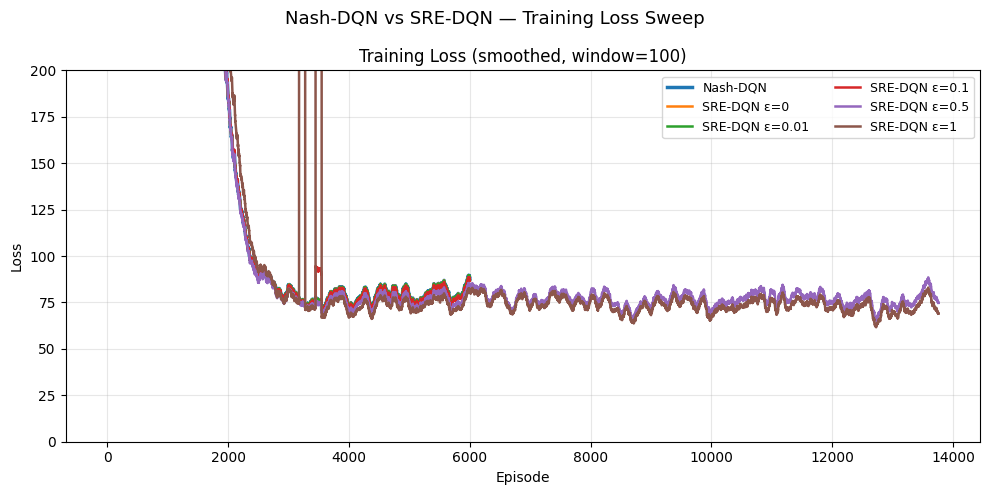

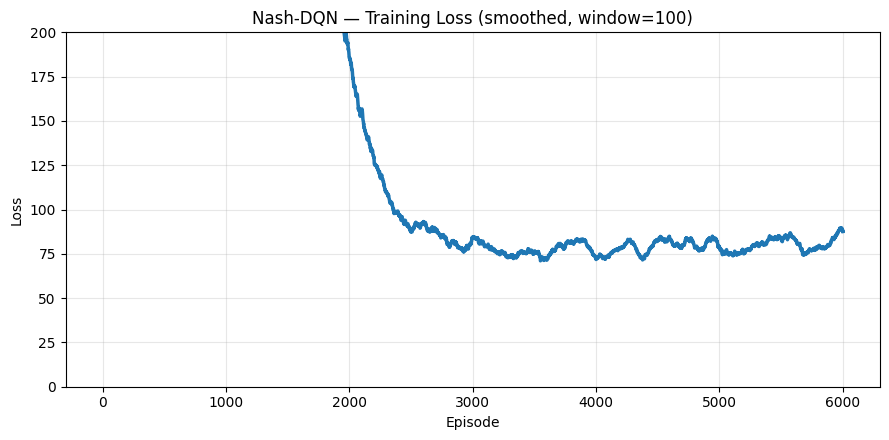

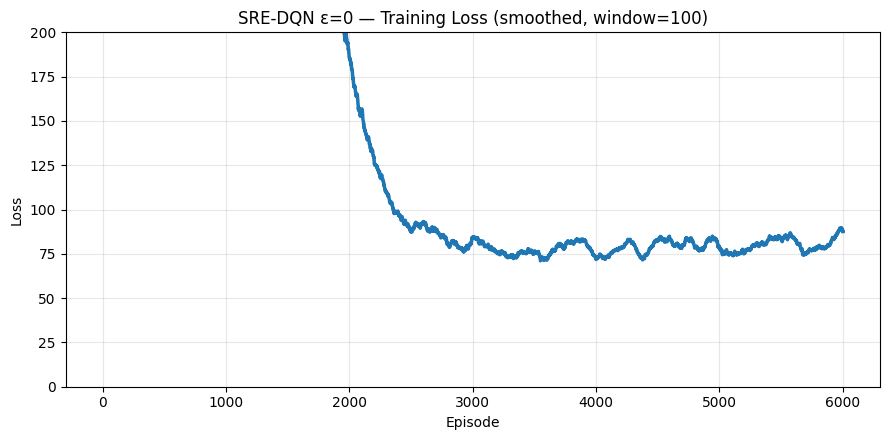

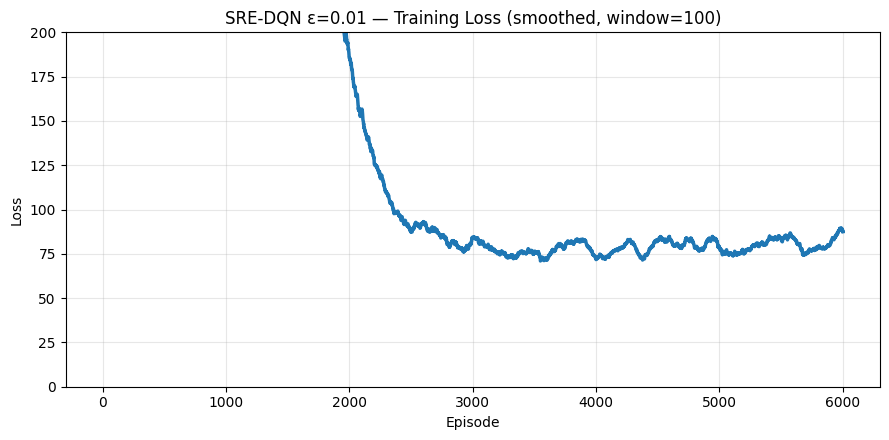

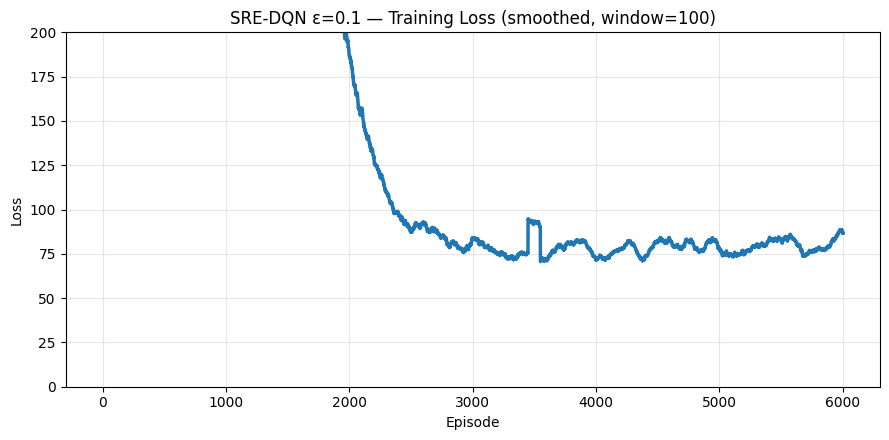

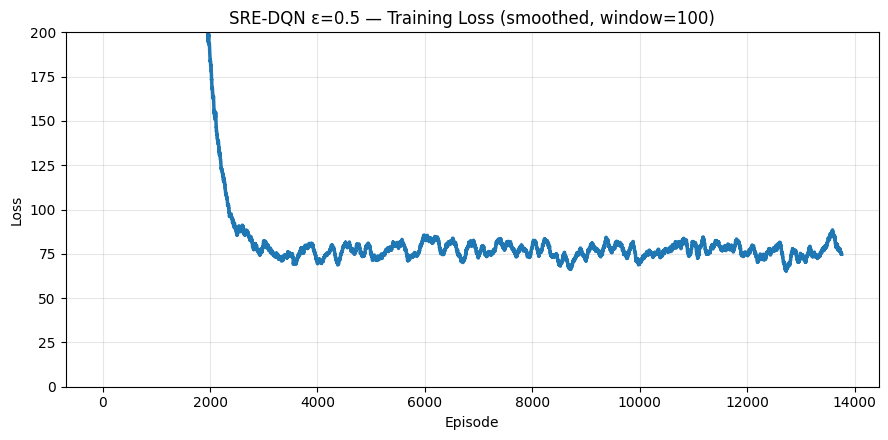

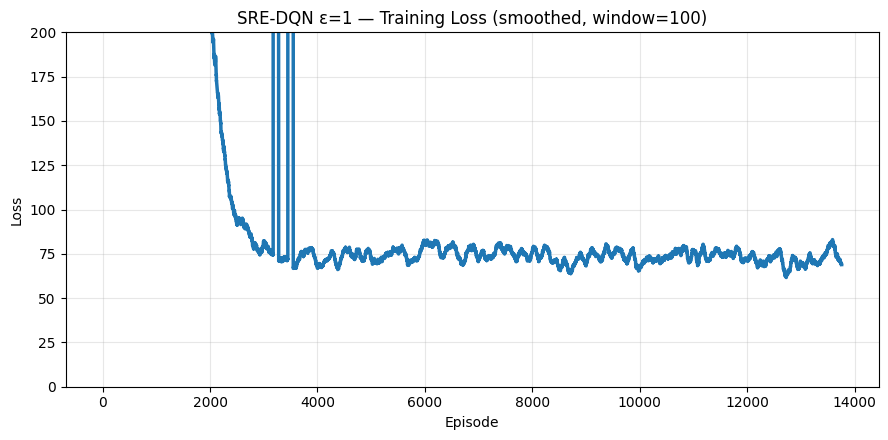

In [6]:

def smooth(arr, window=100):
    arr = np.asarray(arr)
    if len(arr) < window:
        return arr
    kernel = np.ones(window) / window
    return np.convolve(arr, kernel, mode='valid')


SMOOTH_WINDOW = 100

# Combined comparison figure
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(smooth(nash_loss, window=SMOOTH_WINDOW), linewidth=2.5, label='Nash-DQN')
for eps in SRE_EPS_LIST:
    ax.plot(smooth(sre_losses[eps], window=SMOOTH_WINDOW), linewidth=1.8, label=f'SRE-DQN ε={eps:g}')
ax.set_ylim(0, 200)
ax.set_xlabel('Episode')
ax.set_ylabel('Loss')
ax.set_title(f'Training Loss (smoothed, window={SMOOTH_WINDOW})')
ax.legend(ncol=2, fontsize=9)
ax.grid(alpha=0.3)

fig.suptitle('Nash-DQN vs SRE-DQN — Training Loss Sweep', fontsize=13)
plt.tight_layout()
os.makedirs(EVAL_DIR, exist_ok=True)
fig.savefig(os.path.join(EVAL_DIR, 'training_loss_sweep_smoothed.png'), dpi=150, bbox_inches='tight')
plt.show()

# Individual model figures
individual_specs = [
    ('Nash-DQN', nash_loss, 'training_loss_nash_smoothed.png'),
] + [
    (f'SRE-DQN ε={eps:g}', sre_losses[eps], f'training_loss_sre_eps_{eps_slug(eps)}_smoothed.png')
    for eps in SRE_EPS_LIST
]

for label, loss_arr, file_name in individual_specs:
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(smooth(loss_arr, window=SMOOTH_WINDOW), linewidth=2.5)
    ax.set_ylim(0, 200)
    ax.set_xlabel('Episode')
    ax.set_ylabel('Loss')
    ax.set_title(f'{label} — Training Loss (smoothed, window={SMOOTH_WINDOW})')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    fig.savefig(os.path.join(EVAL_DIR, file_name), dpi=150, bbox_inches='tight')
    plt.show()


## Policy Heatmaps — Nash-DQN

Each panel shows the optimal action (trade rate) as a function of (time remaining, inventory) at a fixed price level.

=== Nash-DQN Policy Heatmaps ===
[ 9.5   9.75 10.   10.25 10.5 ]


/home/wowthecoder/SRE-DQN/continous_action_space/visualization.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_list.append(State(t=torch.tensor(T-t).cuda().float(),


[ 9.5   9.75 10.   10.25 10.5 ]


/home/wowthecoder/SRE-DQN/continous_action_space/visualization.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_list.append(State(t=torch.tensor(T-t).cuda().float(),


[ 9.5   9.75 10.   10.25 10.5 ]


/home/wowthecoder/SRE-DQN/continous_action_space/visualization.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_list.append(State(t=torch.tensor(T-t).cuda().float(),


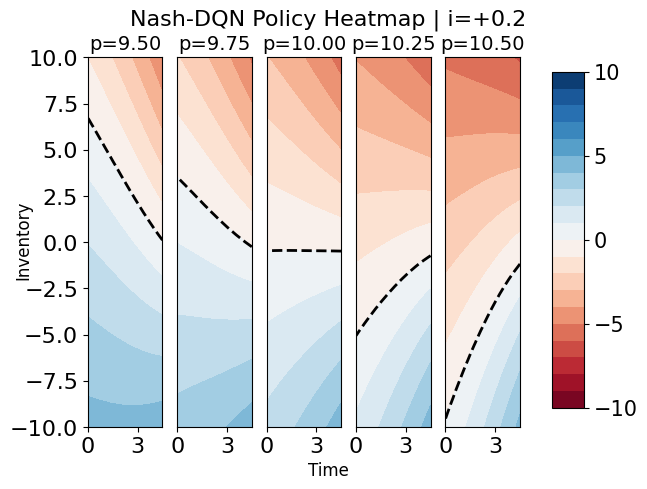

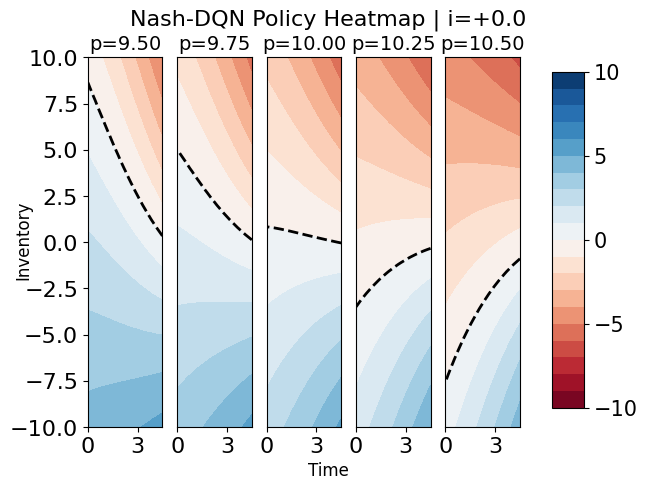

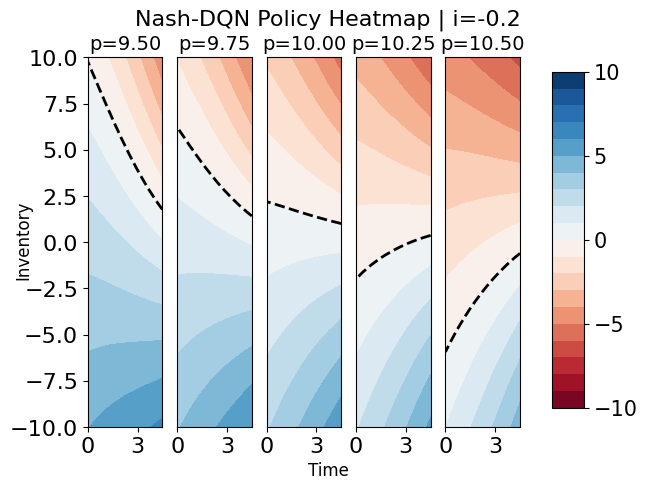

In [7]:

heatmap_kwargs = dict(
    t_step=11, q_step=51, p_step=5,
    t_range=[0, 4.5],
    q_range=[-10, 10],
    p_range=[9.5, 10.5],
    n_agents=num_players,
    other_agent_inv=0,
    a_range=[-10, 10],
    T=T,
    norm_mean=norm_mean,
    norm_std=norm_std,
    is_numpy=False,
    norm_input=True,
)

print('=== Nash-DQN Policy Heatmaps ===')
for i_val in [0.2, 0.0, -0.2]:
    draw_heatmap(
        net=nash_agent,
        i_val=i_val,
        file_path=os.path.join(NASH_MODEL_DIR, f'policy_heatmap_nash_i{i_val:+.1f}.png'),
        figure_title=f'Nash-DQN Policy Heatmap | i={i_val:+.1f}',
        **heatmap_kwargs,
    )



## Policy Heatmaps — SRE-DQN Sweep

For each trained SRE agent, this section plots the learned Nash action `μ` across the requested epsilon sweep.


=== SRE-DQN Policy Heatmaps (learned Nash mu, epsilon sweep) ===
  ε=0
[ 9.5   9.75 10.   10.25 10.5 ]


/home/wowthecoder/SRE-DQN/continous_action_space/visualization.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_list.append(State(t=torch.tensor(T-t).cuda().float(),


[ 9.5   9.75 10.   10.25 10.5 ]


/home/wowthecoder/SRE-DQN/continous_action_space/visualization.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_list.append(State(t=torch.tensor(T-t).cuda().float(),


[ 9.5   9.75 10.   10.25 10.5 ]


...

/home/wowthecoder/SRE-DQN/continous_action_space/visualization.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_list.append(State(t=torch.tensor(T-t).cuda().float(),


[ 9.5   9.75 10.   10.25 10.5 ]


/home/wowthecoder/SRE-DQN/continous_action_space/visualization.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_list.append(State(t=torch.tensor(T-t).cuda().float(),


[ 9.5   9.75 10.   10.25 10.5 ]


/home/wowthecoder/SRE-DQN/continous_action_space/visualization.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_list.append(State(t=torch.tensor(T-t).cuda().float(),


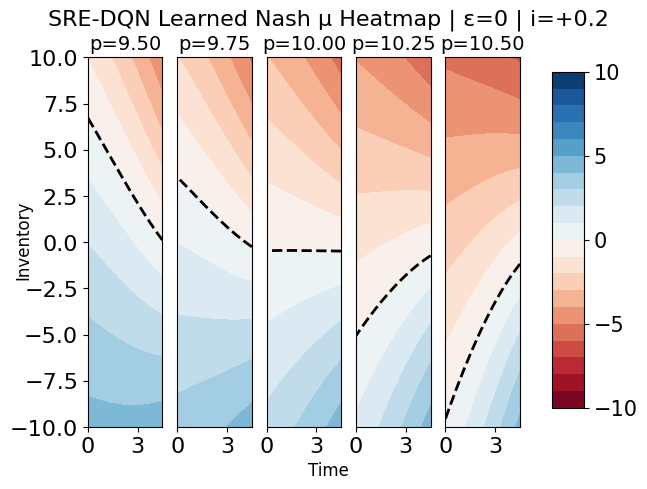

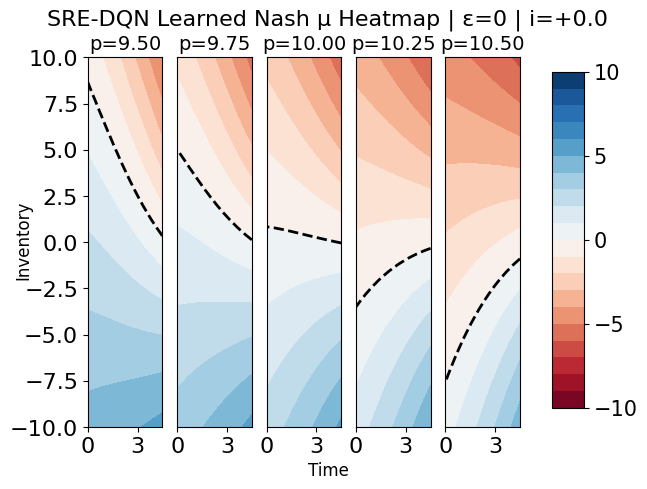

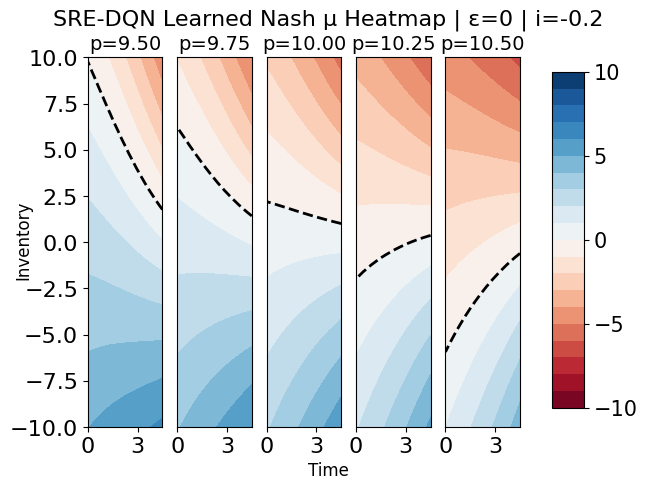

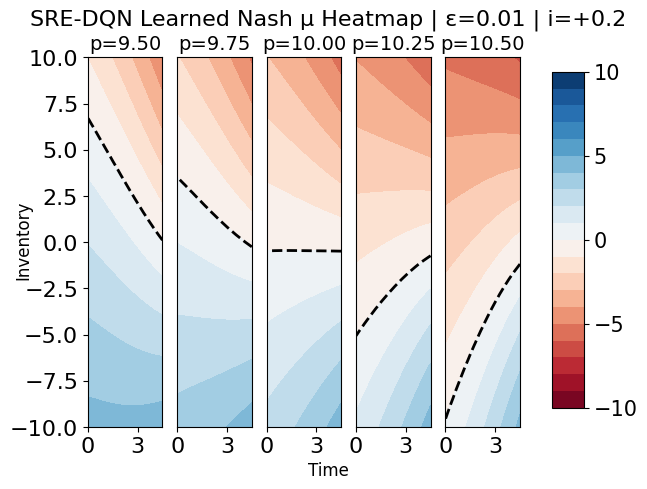

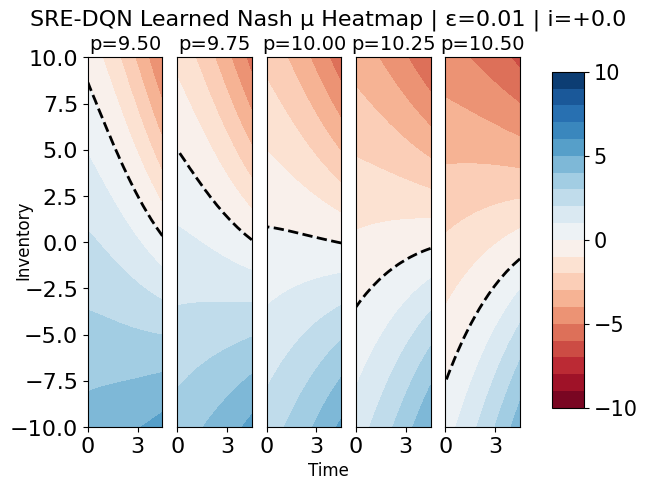

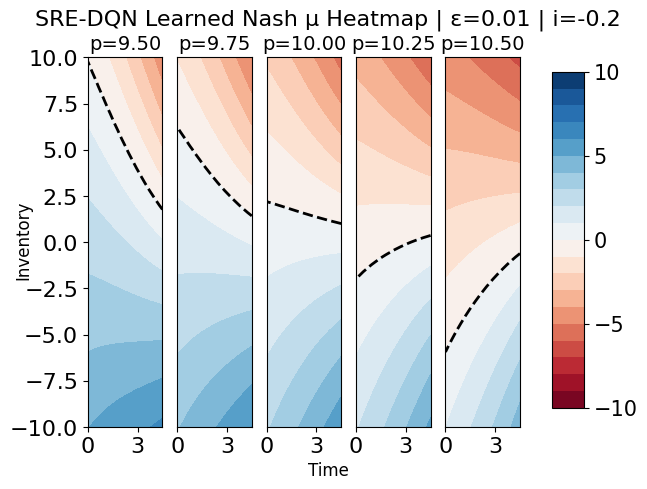

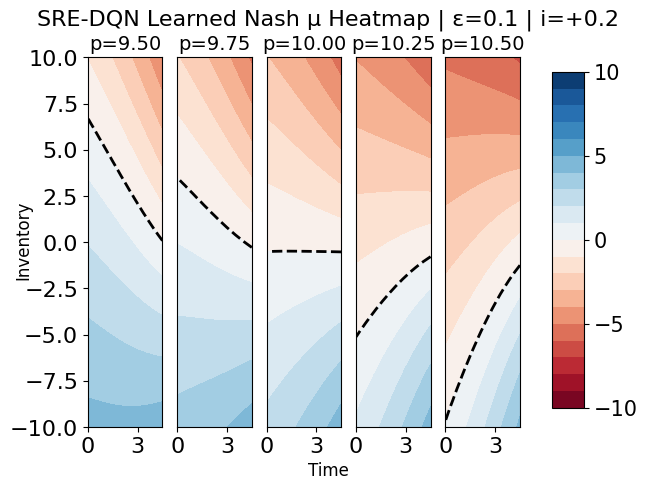

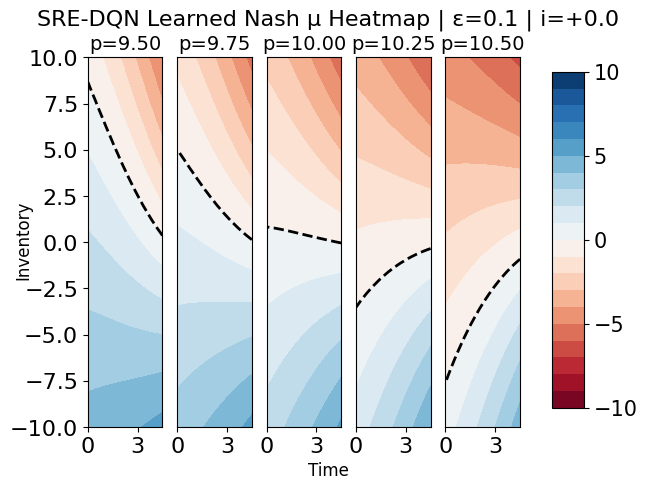

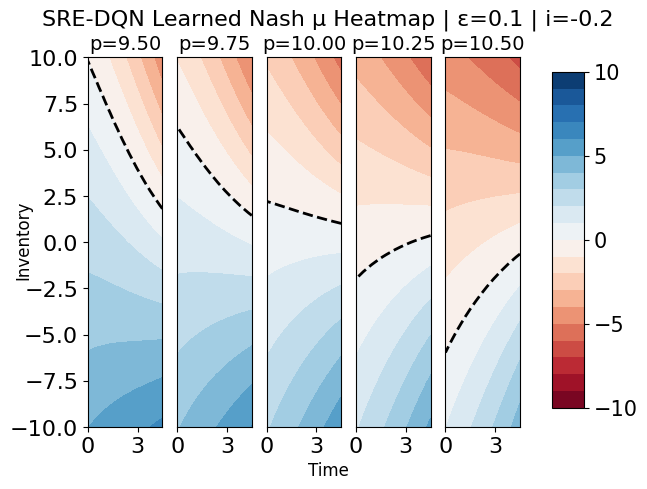

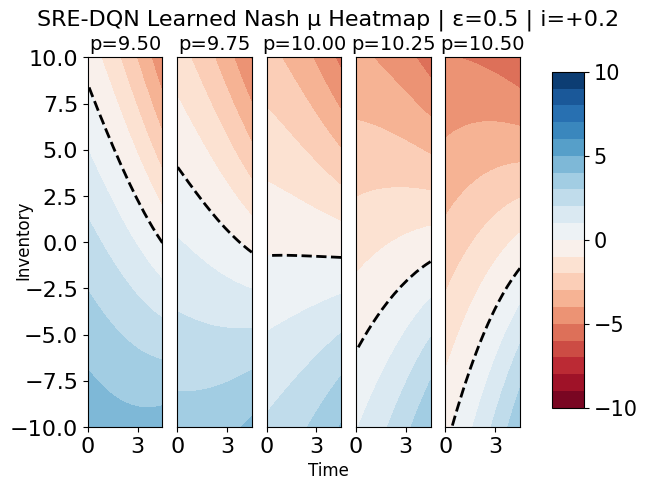

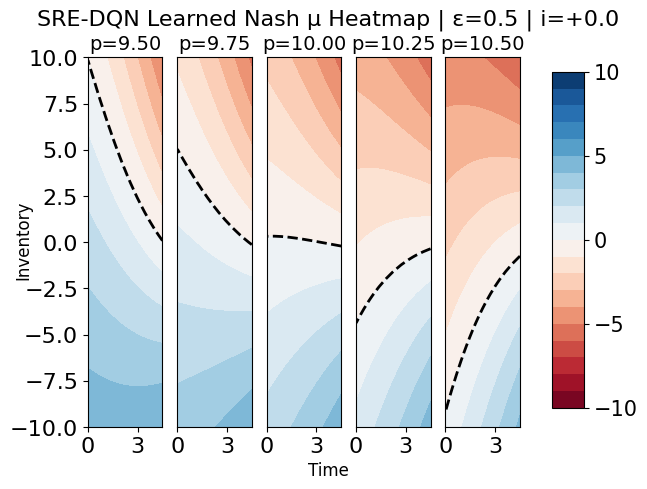

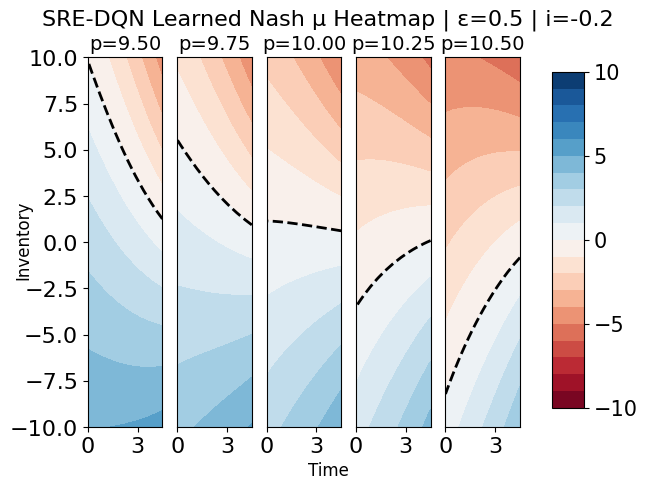

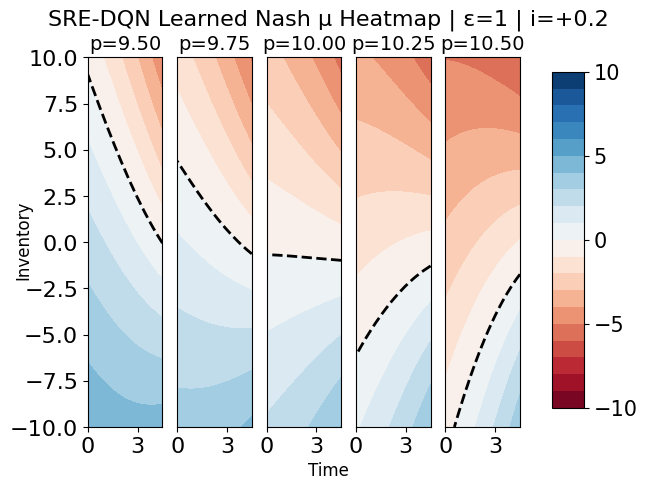

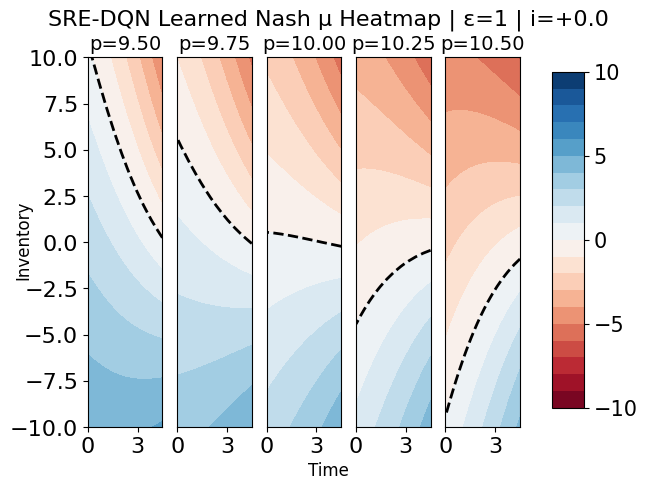

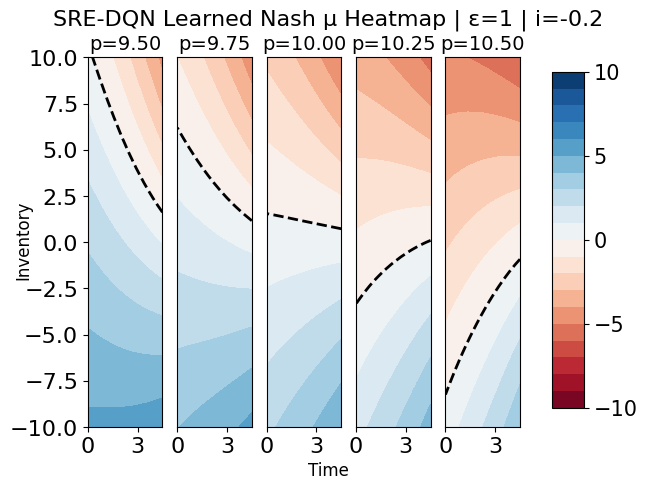

In [8]:

print('=== SRE-DQN Policy Heatmaps (learned Nash mu, epsilon sweep) ===')
for eps in SRE_EPS_LIST:
    eps_fig_dir = SRE_MODEL_DIRS[eps]
    print(f'  ε={eps:g}')
    for i_val in [0.2, 0.0, -0.2]:
        draw_heatmap(
            net=sre_agents[eps],
            i_val=i_val,
            file_path=os.path.join(eps_fig_dir, f'policy_heatmap_sre_mu_eps_{eps_slug(eps)}_i{i_val:+.1f}.png'),
            figure_title=f'SRE-DQN Learned Nash μ Heatmap | ε={eps:g} | i={i_val:+.1f}',
            **heatmap_kwargs,
        )



## Policy Heatmaps — SRE-Corrected Action Sweep

These heatmaps show the actual SRE action `μ^SR = μ + ε·correction` for each trained epsilon, with no epsilon decay.


=== SRE-DQN Corrected Action Heatmaps (epsilon sweep) ===
  ε=0
[ 9.5   9.75 10.   10.25 10.5 ]


/home/wowthecoder/SRE-DQN/continous_action_space/visualization.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_list.append(State(t=torch.tensor(T-t).cuda().float(),


[ 9.5   9.75 10.   10.25 10.5 ]


/home/wowthecoder/SRE-DQN/continous_action_space/visualization.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_list.append(State(t=torch.tensor(T-t).cuda().float(),


[ 9.5   9.75 10.   10.25 10.5 ]


...

/home/wowthecoder/SRE-DQN/continous_action_space/visualization.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_list.append(State(t=torch.tensor(T-t).cuda().float(),


[ 9.5   9.75 10.   10.25 10.5 ]


/home/wowthecoder/SRE-DQN/continous_action_space/visualization.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_list.append(State(t=torch.tensor(T-t).cuda().float(),


[ 9.5   9.75 10.   10.25 10.5 ]


/home/wowthecoder/SRE-DQN/continous_action_space/visualization.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_list.append(State(t=torch.tensor(T-t).cuda().float(),


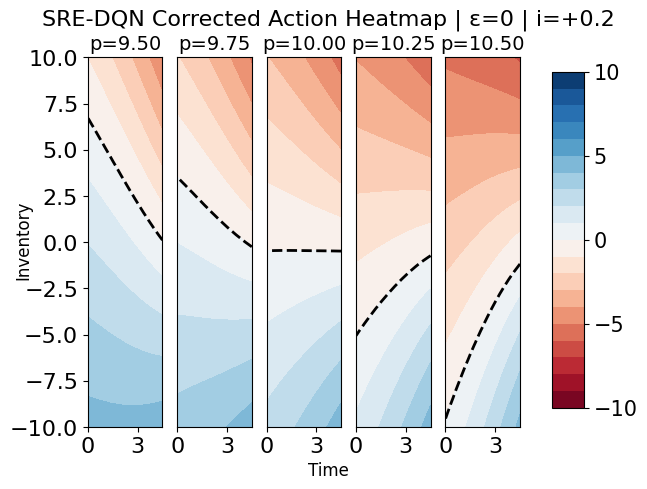

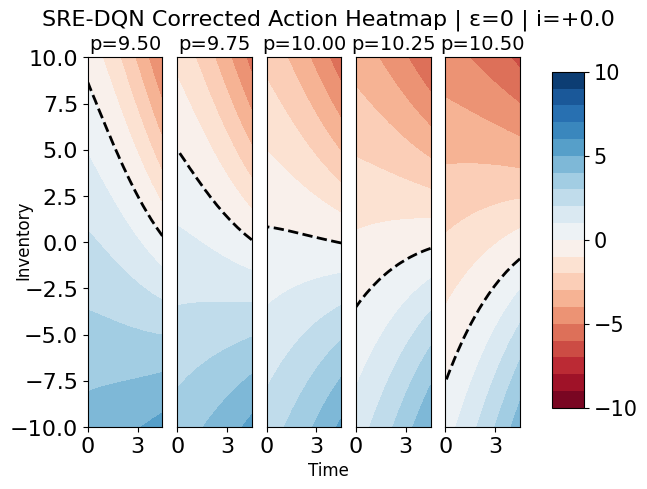

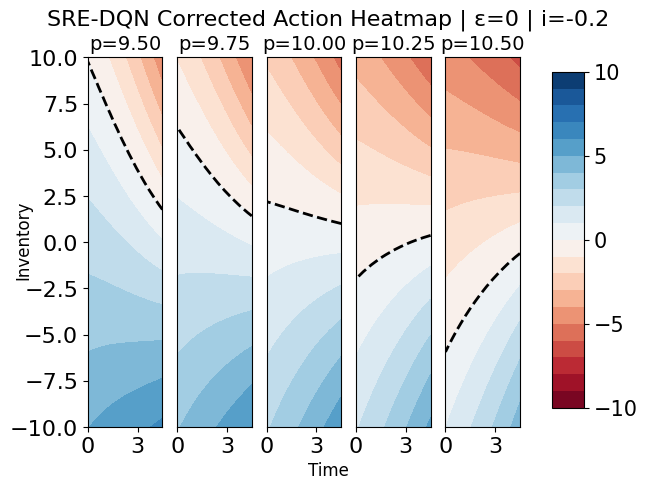

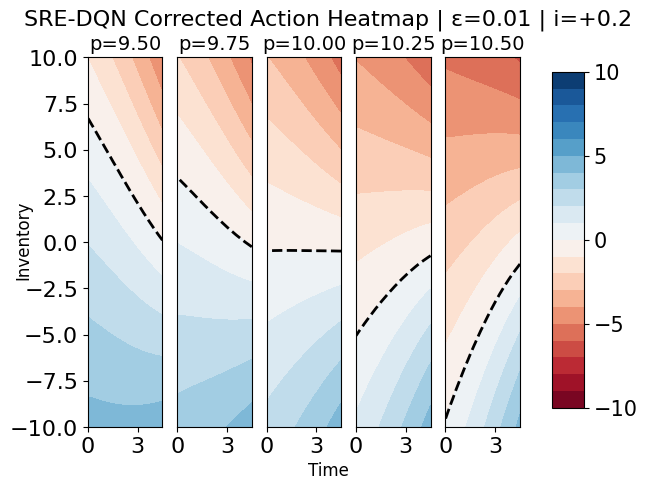

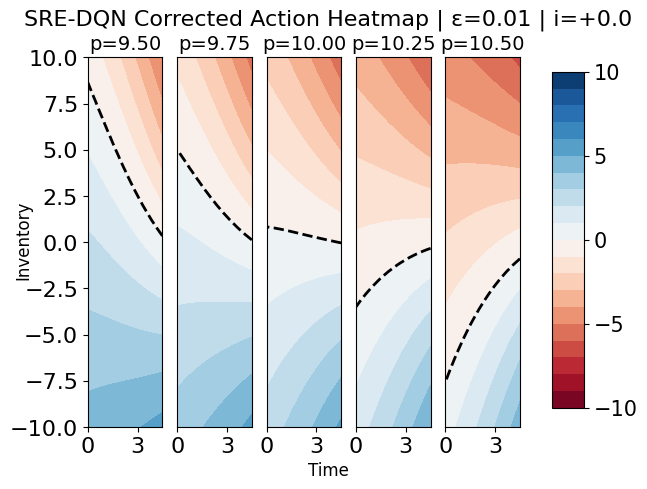

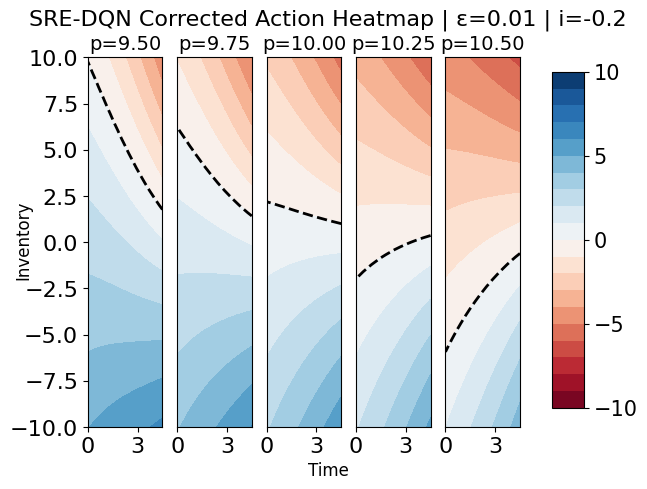

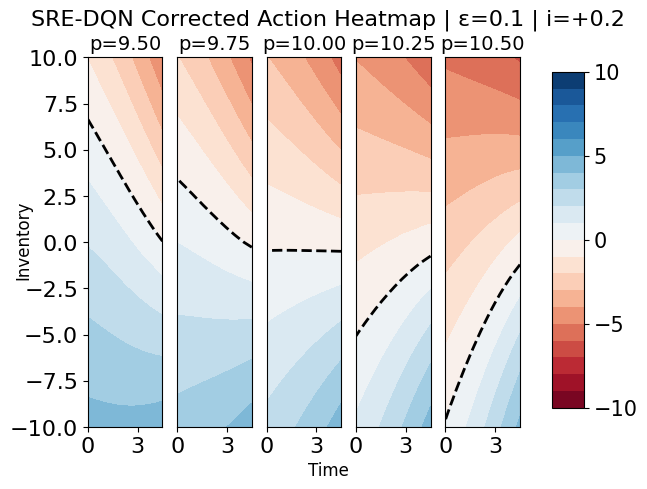

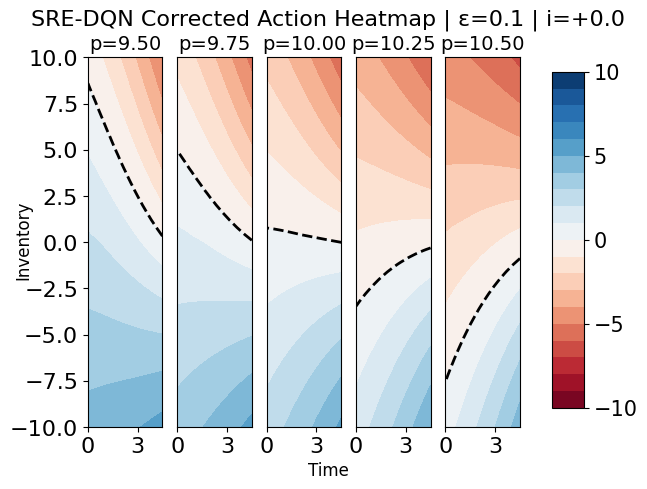

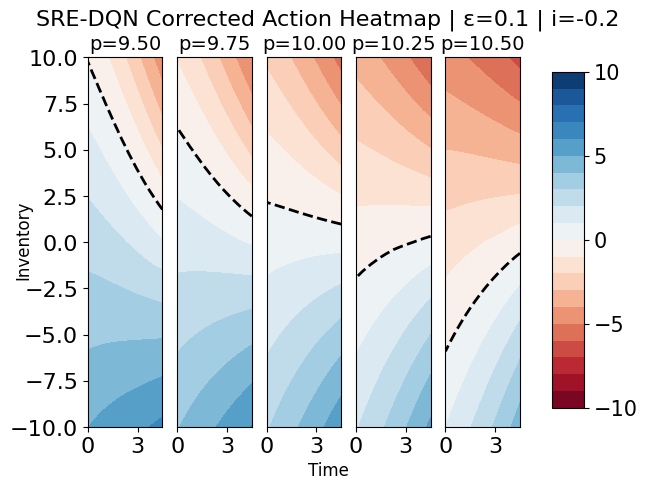

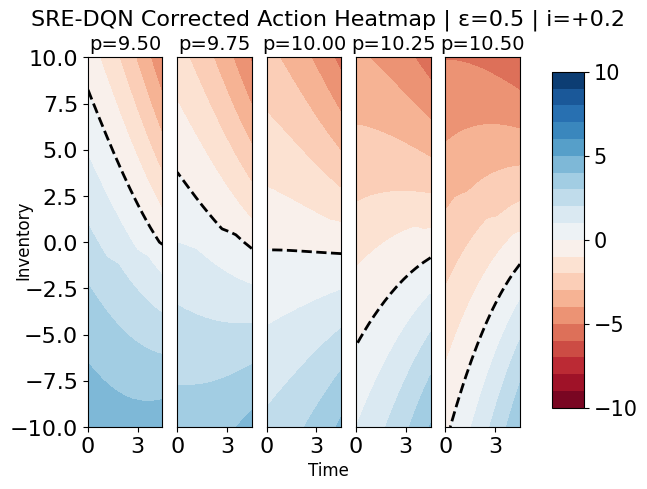

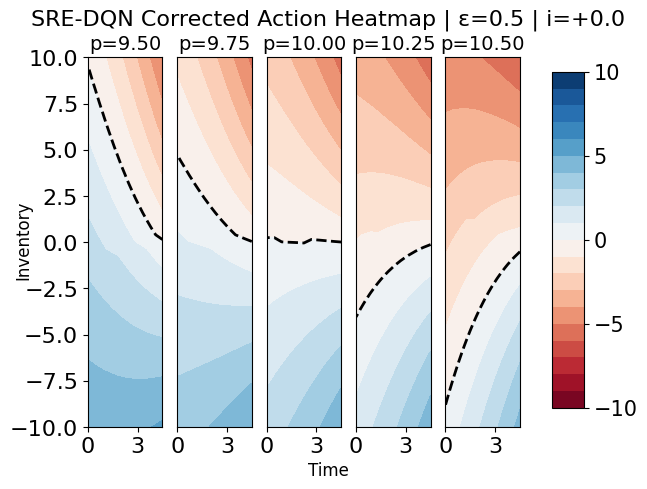

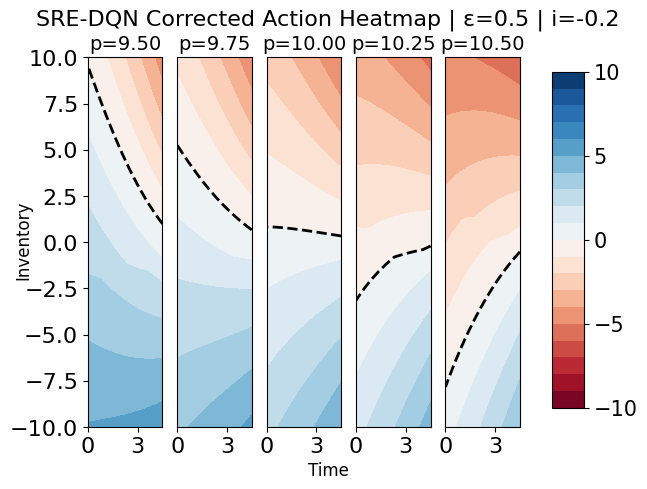

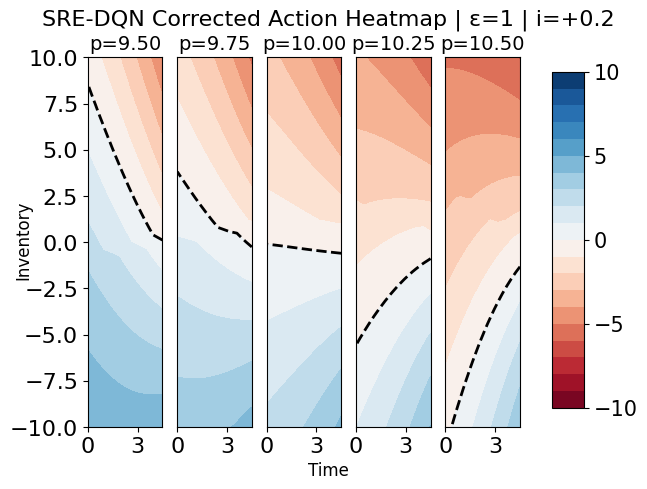

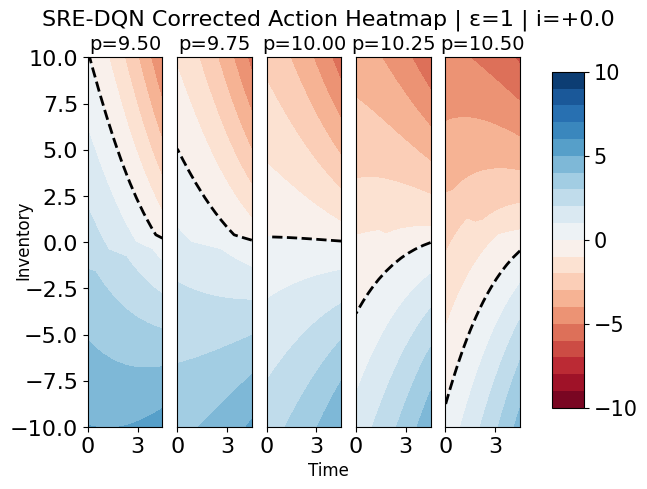

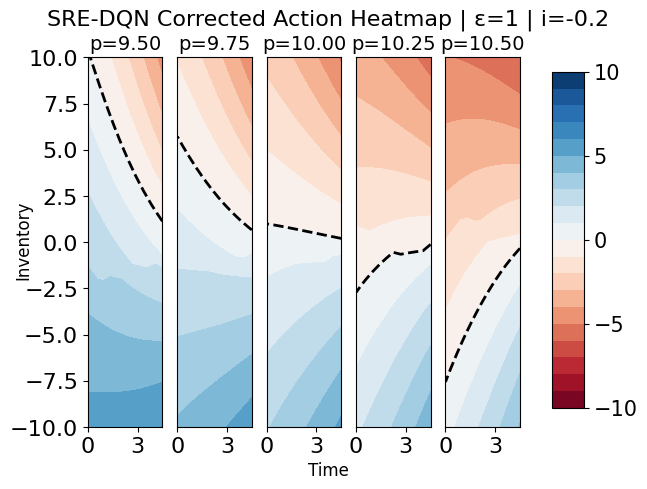

In [9]:

print('=== SRE-DQN Corrected Action Heatmaps (epsilon sweep) ===')
for eps in SRE_EPS_LIST:
    eps_fig_dir = SRE_MODEL_DIRS[eps]
    print(f'  ε={eps:g}')
    for i_val in [0.2, 0.0, -0.2]:
        draw_heatmap(
            net=sre_agents[eps],
            i_val=i_val,
            file_path=os.path.join(eps_fig_dir, f'policy_heatmap_sre_corrected_eps_{eps_slug(eps)}_i{i_val:+.1f}.png'),
            mesh_fn=to_State_mesh_sre,
            mesh_kwargs={'eps': eps},
            figure_title=f'SRE-DQN Corrected Action Heatmap | ε={eps:g} | i={i_val:+.1f}',
            **heatmap_kwargs,
        )


## Evaluation Rollouts

The post-training evaluation uses these six scenarios with fixed seeds and no epsilon decay:

| Scenario | Agent 0 | Agents 1–4 |
|----------|---------|------------|
| All Nash | Nash | Nash |
| All SRE (ε=0.5) | SRE ε=0.5 | SRE ε=0.5 |
| All SRE (ε=1.0) | SRE ε=1.0 | SRE ε=1.0 |
| All SRE mixed | SRE ε=0.0 | SRE ε in {0.01, 0.1, 0.5, 1.0} |
| Nash vs SRE | Nash | SRE ε=0.5 |
| SRE vs Nash | SRE ε=0.5 | Nash |


In [10]:
NUM_TRIALS = 50
IT_LIM = 500  # episodes per trial
EVAL_BATCH_SIZE = 2000


def make_policy_spec(agent, mode, eps=None):
    return {'agent': agent, 'mode': mode, 'eps': eps}


def per_agent_action(spec, states, invt_states):
    if spec['mode'] == 'nash':
        return spec['agent'].predict_action(states, invt_states)[:, 4]
    if spec['mode'] == 'sre':
        return spec['agent'].compute_sre_action(states, invt_states, spec['eps'])
    raise ValueError(f"Unknown policy mode: {spec['mode']}")


def collect_mixed_rewards(
    sim,
    norm_mean,
    norm_std,
    policy_specs,
    num_trials,
    it_lim,
    seed,
    desc=None,
    eval_batch_size=2000,
):
    if len(policy_specs) != sim.N:
        raise ValueError(f'Expected {sim.N} policy specs, got {len(policy_specs)}')

    total_episodes = num_trials * it_lim
    n_steps = int(sim.T / sim.dt)
    device = next(policy_specs[0]['agent'].action_net.parameters()).device

    if eval_batch_size <= 0:
        raise ValueError(f'eval_batch_size must be > 0, got {eval_batch_size}')

    if desc is not None:
        print(desc)

    seed_everything(seed)
    chunk_rewards = []

    for start in range(0, total_episodes, eval_batch_size):
        end = min(start + eval_batch_size, total_episodes)
        bs = end - start

        def action_fn(cur_s, cur_ivt, bs=bs):
            state_batch = cur_s.view(bs, sim.N, -1)
            invt_batch = None if cur_ivt is None else cur_ivt.view(bs, sim.N, -1)
            all_actions = []

            for agent_idx, spec in enumerate(policy_specs):
                agent_states = state_batch[:, agent_idx, :]
                agent_invt = None if invt_batch is None else invt_batch[:, agent_idx, :]
                all_actions.append(per_agent_action(spec, agent_states, agent_invt))

            return torch.stack(all_actions, dim=1)

        replay_sample = collect_parallel_rollouts(
            sim_obj=sim,
            max_steps=n_steps,
            mini_batch=bs,
            norm_mean=norm_mean,
            norm_std=norm_std,
            action_fn=action_fn,
            device=device,
        )

        rewards = replay_sample[5].view(n_steps, bs, sim.N)
        rewards = rewards.permute(1, 0, 2).contiguous()
        chunk_rewards.append(rewards.cpu())

    rewards = torch.cat(chunk_rewards, dim=0)
    if rewards.shape[0] != total_episodes:
        raise RuntimeError(
            f'Collected {rewards.shape[0]} episodes but expected {total_episodes}'
        )
    return rewards.view(num_trials, it_lim, n_steps, sim.N)


nash_spec = make_policy_spec(nash_agent, mode='nash')
sre_05_spec = make_policy_spec(sre_agents[0.5], mode='sre', eps=0.5)
sre_10_spec = make_policy_spec(sre_agents[1.0], mode='sre', eps=1.0)

scenario_specs = [
    ('All Nash', [nash_spec for _ in range(num_players)]),
    ('All SRE (eps=0.5)', [sre_05_spec for _ in range(num_players)]),
    ('All SRE (eps=1.0)', [sre_10_spec for _ in range(num_players)]),
    (
        'All SRE Mixed (0,0.01,0.1,0.5,1.0)',
        [make_policy_spec(sre_agents[eps], mode='sre', eps=eps) for eps in SRE_EPS_LIST],
    ),
    ('Nash vs SRE (agent 0 Nash)', [nash_spec] + [sre_05_spec for _ in range(num_players - 1)]),
    ('SRE vs Nash (agent 0 SRE)', [sre_05_spec] + [nash_spec for _ in range(num_players - 1)]),
]

scenario_rewards = {}
for scenario_name, policy_specs in scenario_specs:
    scenario_rewards[scenario_name] = collect_mixed_rewards(
        sim_obj,
        norm_mean,
        norm_std,
        policy_specs,
        NUM_TRIALS,
        IT_LIM,
        seed=EVAL_SEED,
        desc=f'Collecting {scenario_name} rollouts...',
        eval_batch_size=EVAL_BATCH_SIZE,
    )

all_nash_rewards = scenario_rewards['All Nash']
all_sre_05_rewards = scenario_rewards['All SRE (eps=0.5)']
all_sre_10_rewards = scenario_rewards['All SRE (eps=1.0)']
all_sre_mixed_rewards = scenario_rewards['All SRE Mixed (0,0.01,0.1,0.5,1.0)']
nash_vs_sre_rewards = scenario_rewards['Nash vs SRE (agent 0 Nash)']
sre_vs_nash_rewards = scenario_rewards['SRE vs Nash (agent 0 SRE)']

print('Done.')


Done.


## Reward Distribution Histograms

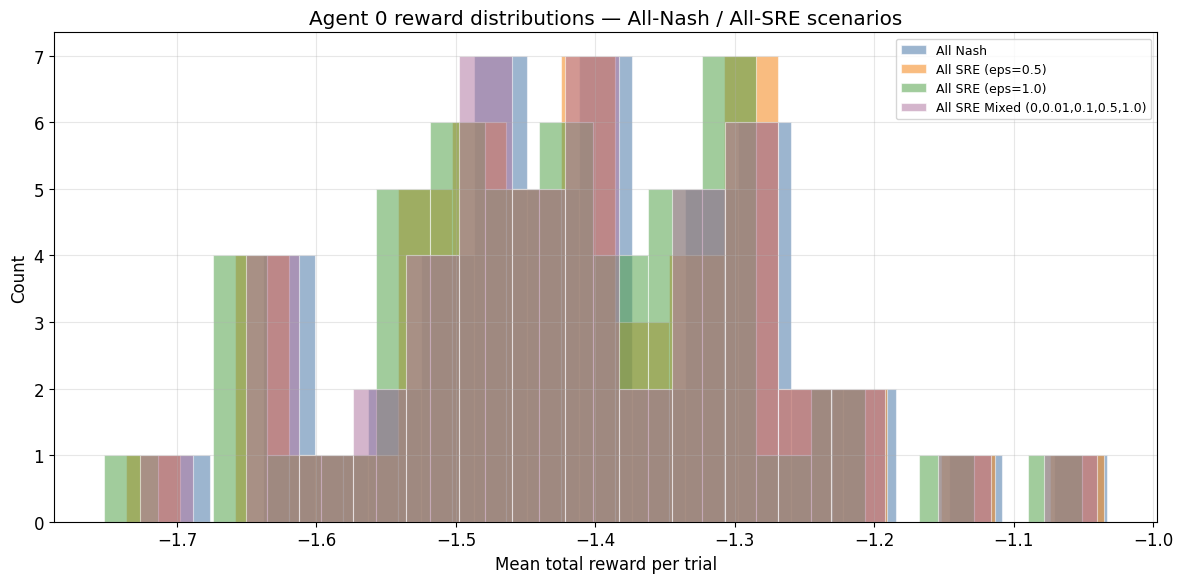

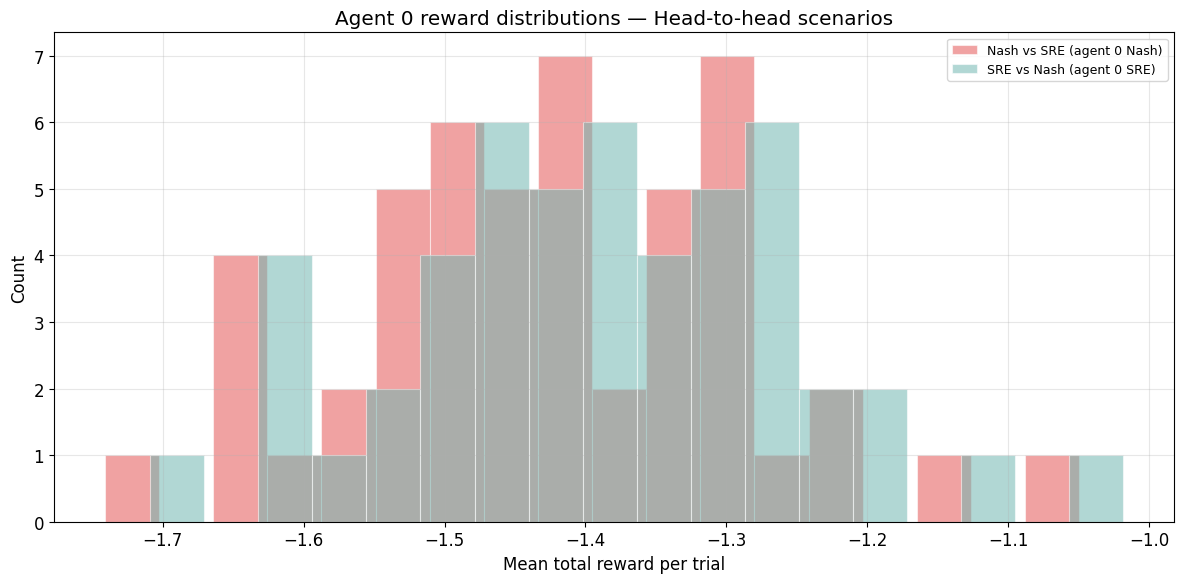

/tmp/ipykernel_15093/3011337835.py:74: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


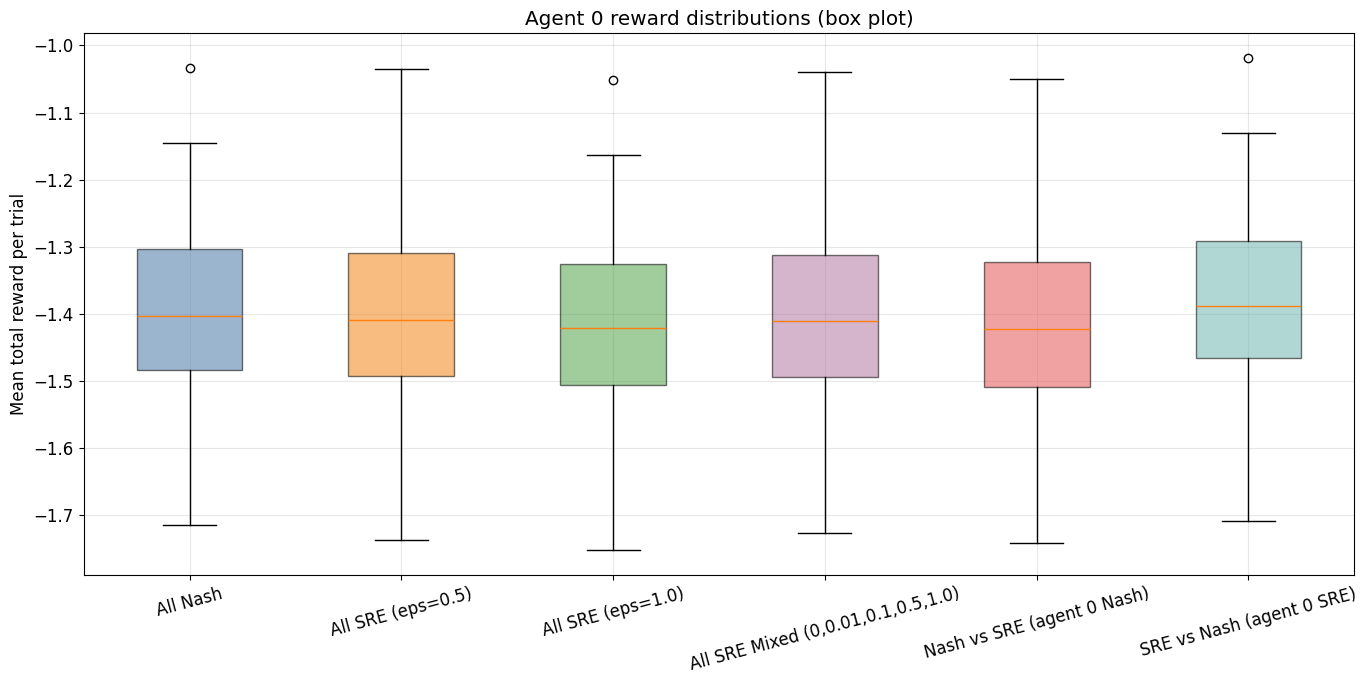

In [14]:

def agent0_mean_total_reward(rewards):
    """Mean total reward for agent 0, averaged over episodes, per trial.
    rewards shape: [num_trials, it_lim, n_steps, n_agents]
    """
    return rewards.sum(dim=2)[..., 0].mean(dim=1).cpu().numpy()


scenario_agent0_rewards = {
    name: agent0_mean_total_reward(rewards)
    for name, rewards in scenario_rewards.items()
}

scenario_names = list(scenario_agent0_rewards.keys())
scenario_arrays = [scenario_agent0_rewards[name] for name in scenario_names]
scenario_colors = {
    'All Nash': '#4C78A8',
    'All SRE (eps=0.5)': '#F58518',
    'All SRE (eps=1.0)': '#54A24B',
    'All SRE Mixed (0,0.01,0.1,0.5,1.0)': '#B279A2',
    'Nash vs SRE (agent 0 Nash)': '#E45756',
    'SRE vs Nash (agent 0 SRE)': '#72B7B2',
}

histogram_groups = [
    (
        'Agent 0 reward distributions — All-Nash / All-SRE scenarios',
        [
            'All Nash',
            'All SRE (eps=0.5)',
            'All SRE (eps=1.0)',
            'All SRE Mixed (0,0.01,0.1,0.5,1.0)',
        ],
        'reward_histogram_all_nash_vs_all_sre.png',
    ),
    (
        'Agent 0 reward distributions — Head-to-head scenarios',
        [
            'Nash vs SRE (agent 0 Nash)',
            'SRE vs Nash (agent 0 SRE)',
        ],
        'reward_histogram_nash_vs_sre_matchups.png',
    ),
]


def plot_histogram_group(title, names, file_name, bins=18):
    fig, ax = plt.subplots(figsize=(12, 6))
    for name in names:
        ax.hist(
            scenario_agent0_rewards[name],
            bins=bins,
            alpha=0.55,
            label=name,
            color=scenario_colors[name],
            edgecolor='white',
            linewidth=0.8,
        )
    ax.set_title(title)
    ax.set_xlabel('Mean total reward per trial')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    fig.savefig(os.path.join(EVAL_DIR, file_name), dpi=150, bbox_inches='tight')
    plt.show()


os.makedirs(EVAL_DIR, exist_ok=True)
for title, names, file_name in histogram_groups:
    plot_histogram_group(title, names, file_name)

# Box plot across all scenarios
fig, ax = plt.subplots(figsize=(14, 7))
box = ax.boxplot(
    scenario_arrays,
    labels=scenario_names,
    patch_artist=True,
)
for patch, name in zip(box['boxes'], scenario_names):
    patch.set_facecolor(scenario_colors[name])
    patch.set_alpha(0.55)
ax.set_title('Agent 0 reward distributions (box plot)')
ax.set_ylabel('Mean total reward per trial')
ax.tick_params(axis='x', rotation=15)
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(EVAL_DIR, 'reward_boxplot_scenarios.png'), dpi=150, bbox_inches='tight')
plt.show()


## Statistical Comparison

In [12]:
def describe(arr, name):
    return {
        'scenario': name,
        'mean': float(arr.mean()),
        'std': float(arr.std()),
        'median': float(np.median(arr)),
        'min': float(arr.min()),
        'max': float(arr.max()),
    }


rows = [describe(arr, name) for name, arr in scenario_agent0_rewards.items()]

print(f"{'Scenario':<36} {'Mean':>8} {'Std':>8} {'Median':>8} {'Min':>8} {'Max':>8}")
print('-' * 84)
for row in rows:
    print(
        f"{row['scenario']:<36} {row['mean']:8.4f} {row['std']:8.4f} "
        f"{row['median']:8.4f} {row['min']:8.4f} {row['max']:8.4f}"
    )

print()

t_stat, p_val = stats.ttest_ind(
    scenario_agent0_rewards['All Nash'],
    scenario_agent0_rewards['All SRE (eps=0.5)'],
    equal_var=False,
)
print(f"Welch t-test (All Nash vs All SRE eps=0.5): t={t_stat:.3f}, p={p_val:.4f}")

t_stat2, p_val2 = stats.ttest_ind(
    scenario_agent0_rewards['All Nash'],
    scenario_agent0_rewards['All SRE (eps=1.0)'],
    equal_var=False,
)
print(f"Welch t-test (All Nash vs All SRE eps=1.0): t={t_stat2:.3f}, p={p_val2:.4f}")

t_stat3, p_val3 = stats.ttest_ind(
    scenario_agent0_rewards['SRE vs Nash (agent 0 SRE)'],
    scenario_agent0_rewards['Nash vs SRE (agent 0 Nash)'],
    equal_var=False,
)
print(f"Welch t-test (SRE-vs-Nash vs Nash-vs-SRE): t={t_stat3:.3f}, p={p_val3:.4f}")

win_rate = float((
    scenario_agent0_rewards['SRE vs Nash (agent 0 SRE)']
    > scenario_agent0_rewards['Nash vs SRE (agent 0 Nash)']
).mean())
print(f'Win rate: SRE agent 0 beats Nash agent 0 in {win_rate * 100:.1f}% of trials')


Scenario                                 Mean      Std   Median      Min      Max
------------------------------------------------------------------------------------
All Nash                              -1.4027   0.1350  -1.4032  -1.7144  -1.0329
All SRE (eps=0.5)                     -1.4097   0.1368  -1.4086  -1.7365  -1.0354
All SRE (eps=1.0)                     -1.4251   0.1363  -1.4216  -1.7523  -1.0507
All SRE Mixed (0,0.01,0.1,0.5,1.0)    -1.4124   0.1357  -1.4109  -1.7266  -1.0401
Nash vs SRE (agent 0 Nash)            -1.4247   0.1368  -1.4233  -1.7410  -1.0496
SRE vs Nash (agent 0 SRE)             -1.3872   0.1349  -1.3878  -1.7088  -1.0186

Welch t-test (All Nash vs All SRE eps=0.5): t=0.255, p=0.7991
Welch t-test (All Nash vs All SRE eps=1.0): t=0.816, p=0.4162
Welch t-test (SRE-vs-Nash vs Nash-vs-SRE): t=1.364, p=0.1757
Win rate: SRE agent 0 beats Nash agent 0 in 100.0% of trials


## Save Results

In [13]:
comparison_dict = {
    'nash_loss': nash_loss,
    'sre_losses': sre_losses,
    'scenario_rewards': scenario_rewards,
    'scenario_agent0_rewards': scenario_agent0_rewards,
    'config': {
        'BASE_SEED': BASE_SEED,
        'EVAL_SEED': EVAL_SEED,
        'MAX_STEPS': MAX_STEPS,
        'NUM_TRIALS': NUM_TRIALS,
        'IT_LIM': IT_LIM,
        'EVAL_BATCH_SIZE': EVAL_BATCH_SIZE,
        'SRE_EPS_LIST': SRE_EPS_LIST,
        'SRE_EPS_REG': SRE_EPS_REG,
        'nash_best_checkpoint_path': nash_best_checkpoint_path,
        'sre_best_checkpoint_paths': sre_best_checkpoint_paths,
        'loaded_from_latest_pt_files': True,
        'nash_model_dir': NASH_MODEL_DIR,
        'sre_model_dirs': SRE_MODEL_DIRS,
        'evaluation_dir': EVAL_DIR,
    },
}

out_path = os.path.join(EVAL_DIR, 'sre_vs_nash_comparison.pickle')
with open(out_path, 'wb') as f:
    pickle.dump(comparison_dict, f)
print('Saved comparison results to:', out_path)


Saved comparison results to: evaluation/20260411_2312/sre_vs_nash_comparison.pickle
